<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex01_YOLO_%EB%B6%84%EB%A5%98%EC%8B%A4%EC%8A%B5(%EC%9D%8C%EC%8B%9D%EC%82%AC%EC%A7%84)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# cpu-> gpu
# 드라이브
# cd : YOLO_study
%cd '/content/drive/MyDrive/Colab Notebooks/250915 산대특클라우드 딥러닝/YOLO_study'

/content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study


## 목표
 - 출처:  https://www.kaggle.com/datasets/kmader/food41
 - kaggle 에서 제공된 음식 이미지 사진을 활용하여, YOLO 모델의 분류 Task(과제) 를 수행해보자
 - 음식 이미지 데이터셋으로 커스텀 YOLO모델을 만들어보자
 - YOLO모델이 이해할 수 있는 데이터의 구조로 변경해보는 과정을 알아보자

In [ ]:
# food: apple_pie, donuts, onion_rings, pizza
# 4개의 클래스가 존재

In [ ]:
# food.zip 압축 해제
# zipfile > ZipFile(), extractall('해제경로')
# %cd 와 같은 명령을 통해서도 압축 해제가 가능
!unzip ./data/food.zip -d ./data/food/

# ./data/food.zip : 압축 해제 대상 경로 설정
# -d ./data/food/ : 압축 해제 후 저장할 디렉토리 설정

# 현재 이미지 구조
# ./data/food/apple_pie/...jpg
# ./data/food/donuts/...jpg
# ./data/food/onion_rings/...jpg
# ./data/food/pizza/1836888.jpg
# --> kaggle 사이트에서 정리된 폴더 구조 -> yolo모델이 이해할 수 있는 구조가 x

Archive:  ./data/food.zip
   creating: ./data/food/apple_pie/
  inflating: ./data/food/apple_pie/3127422.jpg  
  inflating: ./data/food/apple_pie/2106005.jpg  
  inflating: ./data/food/apple_pie/1847621.jpg  
  inflating: ./data/food/apple_pie/456190.jpg  
  inflating: ./data/food/apple_pie/1461580.jpg  
  inflating: ./data/food/apple_pie/2766725.jpg  
  inflating: ./data/food/apple_pie/222074.jpg  
  inflating: ./data/food/apple_pie/960233.jpg  
  inflating: ./data/food/apple_pie/2439188.jpg  
  inflating: ./data/food/apple_pie/1159801.jpg  
  inflating: ./data/food/apple_pie/2781167.jpg  
  inflating: ./data/food/apple_pie/3335126.jpg  
  inflating: ./data/food/apple_pie/3421349.jpg  
  inflating: ./data/food/apple_pie/1077964.jpg  
  inflating: ./data/food/apple_pie/3748095.jpg  
  inflating: ./data/food/apple_pie/1305678.jpg  
  inflating: ./data/food/apple_pie/1725573.jpg  
  inflating: ./data/food/apple_pie/2704442.jpg  
  inflating: ./data/food/apple_pie/3270291.jpg  
  inflatin

### YOLO 폴더 구조 준비
- 훈련용, 검증용, 평가용으로 분할
- 폴더 구조 가이드라인: https://docs.ultralytics.com/ko/datasets/classify/
- food_for_yolo (전체 폴더 이름)
    - train
        - apple_pie, donuts, ....
    - test
        - apple_pie, donuts, ....
    - val
        - apple_pie, donuts, ....

In [ ]:
import os
# 파일 다루기 위한 라이브러리,
# 파일 이름, 디렉토리 정보 확인, 생성 등 os 관련된 명령을 수행하는 라이브러리

In [ ]:
# 각 이미지 파일명 접근
apple_pie_fn = os.listdir('./data/food/apple_pie') # 1000
donuts_fn = os.listdir('./data/food/donuts')
onion_rings_fn = os.listdir('./data/food/onion_rings')
pizza_fn = os.listdir('./data/food/pizza')
print(len(apple_pie_fn), len(donuts_fn))
print(len(onion_rings_fn), len(pizza_fn))

# 총 4000장
# train, test, val 폴더로 이동시킬 것
# train - 음식1, 음식2,..., 음식4
# 해당 폴더 구조부터 만들고 이동해야함..!

1000 1000
1000 1000


In [ ]:
# 폴더생성하기(train, test, val)
# 해당 폴더가 생성되어 있는가?
# os.path.exists('./data/food/pizza') : 있으면 True
# os.path.exists('./data/food_for_yolo') : 없으면 False

if not os.path.exists('./data/food_for_yolo'):
    # 생성해~ : os.mkdir
    os.mkdir('./data/food_for_yolo')

if not os.path.exists('./data/food_for_yolo/train'):
    os.mkdir('./data/food_for_yolo/train')

if not os.path.exists('./data/food_for_yolo/test'):
    os.mkdir('./data/food_for_yolo/test')

if not os.path.exists('./data/food_for_yolo/val'):
    os.mkdir('./data/food_for_yolo/val')

In [ ]:
# 하위 폴더 생성하기
# ./data/food_for_yolo/train/apple_pie
# ./data/food_for_yolo/train/donuts
# ./data/food_for_yolo/train/onion_rings
# ./data/food_for_yolo/train/pizza

#food_list = ['apple_pie', 'donuts','onion_rings', 'pizza']
food_list = os.listdir('./data/food')
# - 오타 없이 카테고리 이름을 지정하는 명확하고, 신속한 방법
folder_list = ['train','test','val']

for folder in folder_list:
    for food in food_list:
        if not os.path.exists('./data/food_for_yolo/'+folder+'/'+food):
            os.mkdir('./data/food_for_yolo/'+folder+'/'+food)

In [ ]:
# 폴더 생성 여부 확인하기
print('-train:')
print(os.listdir('./data/food_for_yolo/train'))
print('-test:')
print(os.listdir('./data/food_for_yolo/test'))
print('-val:')
print(os.listdir('./data/food_for_yolo/val'))

-train:
['apple_pie', 'donuts', 'onion_rings', 'pizza']
-test:
['apple_pie', 'donuts', 'onion_rings', 'pizza']
-val:
['apple_pie', 'donuts', 'onion_rings', 'pizza']


In [ ]:
# 1000장씩
# train 640
# val 200
# test 160
# gui 로 진행하기에는 많은 양(시간 오래 걸림, 딜레이가 발생)

# * graphic user interface : 버튼, 눈에 보이는 것으로 마우스로 클릭해서 처리

In [ ]:
import shutil # 라이브러리: 파일과 파일 모음에 대한 여러가지 고수준 연산을 제공(이동 포함)
# train set 사진 이동하기
# apple_pie
# * 현재: data/food/apple_pie/....jpg
# 0~640
for img_name in apple_pie_fn[0:640]:
    shutil.move('./data/food/apple_pie/'+img_name,
                './data/food_for_yolo/train/apple_pie/'+img_name)


In [ ]:
# 파일 이동 확인
len(os.listdir('./data/food/apple_pie'))
len(os.listdir('./data/food_for_yolo/train/apple_pie'))

640

In [ ]:
# val
for img_name in apple_pie_fn[640:801]:
    shutil.move('./data/food/apple_pie/'+img_name,
                './data/food_for_yolo/val/apple_pie/'+img_name)

# test
for img_name in apple_pie_fn[801:]:
    shutil.move('./data/food/apple_pie/'+img_name,
                './data/food_for_yolo/test/apple_pie/'+img_name)

In [ ]:
# 파일 이동 확인
len(os.listdir('./data/food/apple_pie'))
print(len(os.listdir('./data/food_for_yolo/train/apple_pie')))
print(len(os.listdir('./data/food_for_yolo/val/apple_pie')))
print(len(os.listdir('./data/food_for_yolo/test/apple_pie')))

640
161
199


In [ ]:
# food_list = os.listdir('./data/food')[:-1]
food_list = ['onion_rings', 'donuts', 'pizza']
food_fn_list = [onion_rings_fn, donuts_fn, pizza_fn]

for food, img_list in zip(food_list, food_fn_list):
    for img_name in img_list[0:640]:
        shutil.move(f'./data/food/{food}/'+img_name,
                    f'./data/food_for_yolo/train/{food}/'+img_name)

    for img_name in img_list[640:801]:
        shutil.move(f'./data/food/{food}/'+img_name,
                    f'./data/food_for_yolo/val/{food}/'+img_name)

    for img_name in img_list[801:]:
        shutil.move(f'./data/food/{food}/'+img_name,
                    f'./data/food_for_yolo/test/{food}/'+img_name)

In [ ]:
# 파일 이동여부 확인
for folder_name in food_list:
    print(len(os.listdir(f'./data/food/{folder_name}')))
    print(len(os.listdir(f'./data/food_for_yolo/train/{folder_name}')))
    print(len(os.listdir(f'./data/food_for_yolo/val/{folder_name}')))
    print(len(os.listdir(f'./data/food_for_yolo/test/{folder_name}')))

0
640
161
199
0
640
161
199
0
640
161
199


### YOLOv11 학습하기
- yolo 모델 사용법 가이드라인:  https://docs.ultralytics.com/usage/cfg/#modes
- cpu 학습 : device='cpu'
- gpu 학습 : 기본값으로 gpu 학습 진행(device=[0,1,2,3,4])

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
# YOLO 클래스: yolo 모델을 불러오기 위한 , 사용하기 위한 도구 모음

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### 모델 불러와서 커스텀 데이터셋 학습 진행
- 음식 분류 데이터셋
- 클래스 : 4개

In [ ]:
# 미리 학습된 모델 가중치 파일을 이용해 YOLO 모델 객체 생성
model = YOLO('yolo11n-cls.pt')

model

YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [ ]:
# 모델 학습 실행
# train: 모델 학습을 위한 함수(기능),
# 다양한 인자(입력되는변수)를 통해 학습 설정을 할 수 있음
#
results = model.train(
    data = './data/food_for_yolo/', # 학습 데이터셋 경로 지정
    epochs= 20,  # 반복횟수
    imgsz = 224  # 입력 이미지의 크기를 224*224 픽셀로 조정하여 학습
)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/food_for_yolo/, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


train: Scanning /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/train... 2560 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2560/2560 5.2it/s 8:12
train: New cache created: /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/train.cache
val: Fast image access ✅ (ping: 1.8±0.6 ms, read: 0.3±0.1 MB/s, size: 53.1 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/val... 644 images, 0 corrupt: 100% ━━━━━━━━━━━━ 644/644 5.3it/s 2:03
val: New cache created: /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentu

In [ ]:
# top1_acc = 가장 확률이 높은 1개가 실제로 정답일 확률  0.947 (95%)
# top5_acc = 가지고 있는 클래스 중에서 상위 5개 확률이 높은 후보 중에서 하나라도
#             정답이 들어있을 확률

# 4개 - 1.0 100%

In [ ]:
# 학습현황에 대한 확인
results.top1
results.top5
# . 으로 키워드에 접근할 수 있음
# best 모델의 저장 위치
# -- train/weights/best.pt
results.save_dir

# train - colab 환경
# predict - vscode, jupyter notebook 환경

PosixPath('/content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/runs/classify/train')

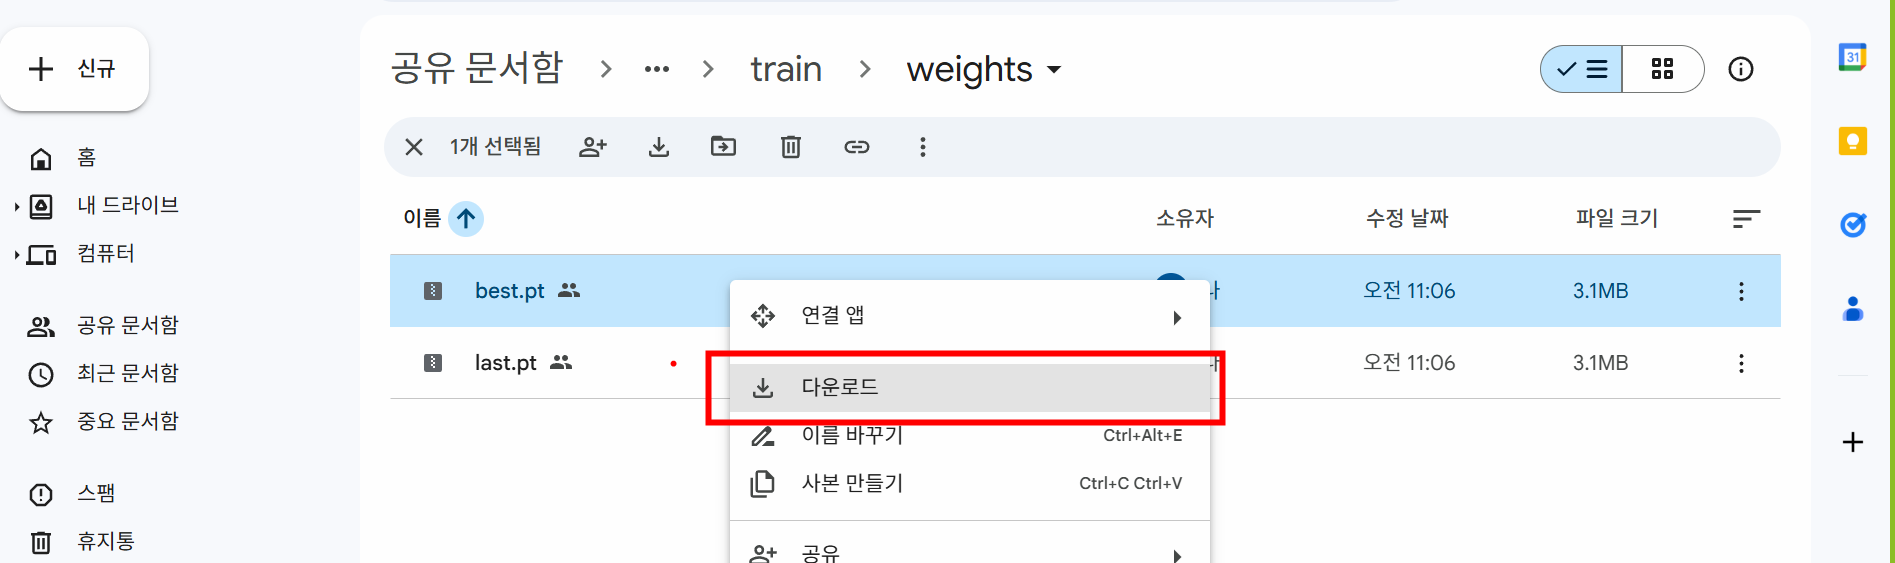

In [ ]:
# 모델 검증하기
model.val()

# top1 : 0.949 95% , train 유사한 성능을 보인
# 과대적합 x, 과소적합x, 일반화가 된 모델 , 성능이 잘 나옴

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-cls summary (fused): 47 layers, 1,531,148 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/train... found 2560 images in 4 classes ✅ 
val: /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/val... found 644 images in 4 classes ✅ 
test: /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/test... found 796 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 30.2±11.7 MB/s, size: 53.1 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/val... 644 images, 0 corrupt: 100% ━━━━━━━━━━━

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e98ac46930>
curves: []
curves_results: []
fitness: 0.9743788838386536
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9487577676773071, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9743788838386536}
save_dir: PosixPath('/content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/runs/classify/train2')
speed: {'preprocess': 0.08108082298343823, 'inference': 1.147187639755588, 'loss': 0.0006759145921170321, 'postprocess': 0.00114551708150582}
task: 'classify'
top1: 0.9487577676773071
top5: 1.0

#### 학습된 모델 예측하기
 - model 변수에 모델 저장
 - best model runs폴더 내부에 저장

In [ ]:
# 런타임이 끊기지 않았기 때문에, 학습 내용 기억 변수(상태)

# model.predict()
pre_result = model('./data/food_for_yolo/test/apple_pie/1147371.jpg')
pre_result


image 1/1 /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/test/apple_pie/1147371.jpg: 224x224 apple_pie 1.00, donuts 0.00, pizza 0.00, onion_rings 0.00, 29.5ms
Speed: 18.5ms preprocess, 29.5ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'apple_pie', 1: 'donuts', 2: 'onion_rings', 3: 'pizza'}
 obb: None
 orig_img: array([[[108, 118, 112],
         [110, 120, 114],
         [114, 121, 116],
         ...,
         [124, 145, 177],
         [123, 144, 176],
         [123, 144, 176]],
 
        [[106, 117, 114],
         [107, 118, 115],
         [109, 118, 115],
         ...,
         [127, 148, 180],
         [126, 147, 179],
         [126, 147, 179]],
 
        [[107, 120, 118],
         [106, 119, 117],
         [108, 119, 117],
         ...,
         [130, 149, 182],
         [128, 149, 181],
         [128, 149, 181]],
 
        ...,
 
        [[183, 192, 201],
         [183, 192, 201],
         [183, 192, 201],
         ...,
         [198, 207, 217],
         [196, 205, 215],
         [194, 203, 213]],
 
        [[182, 191, 200],
         [181, 190, 199],
         [180, 189, 198],
         ...,
       

In [ ]:
# print(pre_result[0].names)
class_names = pre_result[0].names
class_names

{0: 'apple_pie', 1: 'donuts', 2: 'onion_rings', 3: 'pizza'}

In [ ]:
# 전체 확률 정보
print(pre_result[0].probs) # 분류에 대한 결과물을 확인하는 부분
print('------')
print(f'- 예측값: {class_names[pre_result[0].probs.top1]}')
# conf: confidence(확신하는 정도, 확률 정보)
# top1conf: 0.9995 99%만큼 0이라는 클래스로 확신하고 있음
# (0라는 클래스에 대한 확률정보)
# apple_pie라고 실제답과 동일하게(높은 확률로 0이라고 예측) 예측함

ultralytics.engine.results.Probs object with attributes:

data: tensor([9.9952e-01, 3.4532e-04, 4.6474e-07, 1.3471e-04], device='cuda:0')
orig_shape: None
shape: torch.Size([4])
top1: 0
top1conf: tensor(0.9995, device='cuda:0')
top5: [0, 1, 3, 2]
top5conf: tensor([9.9952e-01, 3.4532e-04, 1.3471e-04, 4.6474e-07], device='cuda:0')
------
- 예측값: apple_pie


In [ ]:
# 외부 폴더에 저장된 best 모델 불러오기
# 다중 이미지 예측하기
best_model = YOLO('./runs/classify/train/weights/best.pt')
best_model

YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [ ]:
# best_model(source='./data/food_for_yolo/test/pizza')
pre_results2 = best_model('./data/food_for_yolo/test/pizza', save=True)
len(pre_results2)


image 1/199 /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/test/pizza/1008104.jpg: 224x224 pizza 1.00, apple_pie 0.00, donuts 0.00, onion_rings 0.00, 5.9ms
image 2/199 /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/test/pizza/1008144.jpg: 224x224 apple_pie 0.82, pizza 0.16, donuts 0.02, onion_rings 0.00, 10.3ms
image 3/199 /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/test/pizza/1008844.jpg: 224x224 pizza 0.94, apple_pie 0.06, donuts 0.00, onion_rings 0.00, 4.7ms
image 4/199 /content/drive/.shortcut-targets-by-id/1fSQWYp4SUFBODetqr9kQbZaCsV1uDr8D/250915 산대특클라우드 딥러닝/YOLO_study/data/food_for_yolo/test/pizza/1026922.jpg: 224x224 pizza 1.00, donuts 0.00, apple_pie 0.00, onion_rings 0.00, 4.4ms
image 5/199 /c

199

In [ ]:
# 199개, test 이미지 199
len(pre_results2)
# class_names = pre_result[0].names
# 2번째 인덱스 이미지 예측 결과 확인
for i in range(len(pre_results2)):
    print(class_names[pre_results2[i].probs.top1])

# pizza, apple_pie 혼동되는 것 같음
# 많이는 아님,,
# pizza, apple_pie 이미지를 추가로 더 학습시키는 것도 방법!

pizza
apple_pie
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
donuts
pizza
pizza
apple_pie
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
apple_pie
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
apple_pie
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
apple_pie
pizza
pizza
pizza
pizza
pizza
pizza
donuts
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
apple_pie
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pizza
pi

In [ ]:
pre_results2

# save_dir: ./runs/classify/predict : 기본적으로 문자열이 출력은되지만,
# predict 진행할 때에는 문자열처럼 실제로 저장되지 않음(기본값)

[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'apple_pie', 1: 'donuts', 2: 'onion_rings', 3: 'pizza'}
 obb: None
 orig_img: array([[[ 22,  41,  38],
         [ 18,  37,  34],
         [ 25,  44,  41],
         ...,
         [ 57,  72,  68],
         [ 52,  67,  63],
         [ 47,  62,  58]],
 
        [[ 21,  40,  37],
         [ 16,  35,  32],
         [ 20,  39,  36],
         ...,
         [ 54,  69,  65],
         [ 51,  66,  62],
         [ 48,  63,  59]],
 
        [[ 25,  44,  41],
         [ 21,  40,  37],
         [ 21,  40,  37],
         ...,
         [ 42,  56,  52],
         [ 39,  53,  49],
         [ 38,  52,  48]],
 
        ...,
 
        [[ 84, 114, 109],
         [ 85, 115, 110],
         [ 85, 115, 110],
         ...,
         [ 92, 123, 108],
         [ 87, 120, 106],
         [ 85, 118, 104]],
 
        [[ 85, 115, 110],
         [ 86, 116, 111],
         [ 86, 116, 111],
         ...,
       